In [1]:
from pathlib import Path
# Path.cwd()

In [2]:
import sys
sys.path.insert(0, str(Path.cwd().parent))

In [3]:
from time import perf_counter

from flow import flow_dataclasses, regulator, create
from flow.models.grids import *

n_f = 2 # Number of flowing functions and corresponding exponents
approximation = "NLO"
dim = 1

path_save = 'KPZ_1D_twogrids'

alpha = 2
beta = 1
r = lambda x: regulator.wett_alpha_beta(x, alpha, beta)
r_ = lambda x: regulator.wett_alpha_beta_(x, alpha, beta)

N_p, p_min, p_max = 100, 0.01, 100
N_w, w_min, w_max = 100, 0.01, 100
q_max, deg_q, degtheta = 4, 16, 10

params_grid_external = flow_dataclasses.ParamsGridExternal(N_p=N_p, p_min=p_min, p_max=p_max,
                                                           N_w=N_w, w_min=w_min, w_max=w_max)
params_grid_internal = flow_dataclasses.ParamsGridInternal(deg_q, q_max, degtheta)

model_params = n_f, approximation, dim, params_grid_external, params_grid_internal, r, r_

g_in = 1.
etas_in = np.array([0., 0.])
shape_f = (n_f, N_p, N_w)
fs_in = np.ones(shape_f) # KPZ initial condition

ds = 0.001

IC = flow_dataclasses.IC_NLO(g_in=g_in, etas_in=etas_in, fs_in=fs_in)

evo_params = IC, ds, path_save

### evo2 ###
X_dimful_in = np.array([1., 1.])
match_w_to_p_two = True  # False
p_exit = q_max
Np_two = 200
p_min_two, p_max_two = 0.01, p_exit
Nw_two, w_min_two, w_max_two = Np_two, None, None #p_min_two ** 2, p_exit ** 2 * 10 ** 3
scale = 'log'

evo_two_params = dict(
    X_dimful_in=X_dimful_in,
    match_w_to_p_two=match_w_to_p_two,
    p_exit=p_exit,
    Np_two=Np_two,
    p_min_two=p_min_two, p_max_two=p_max_two,
    Nw_two=Nw_two,
    w_min_two=w_min_two, w_max_two=w_max_two,
    scale=scale,
    s_fin_all_exited=True,
    step_two_action='full', deg_omega=500, omega_max=w_max  ## Record I_dimful
)

flow = create.create('KPZ', model_params, 'evo2', evo_params, evo_two_params)

s_fin = -ds
n_print = 1000
n_save_params = 100
n_save_f = 1000

start = perf_counter()
flow.rg_evolution(s_fin, n_print, n_save_params, n_save_f)
end = perf_counter()
print('time =', end - start)


1D versions are used: theta = [0.         3.14159265] wtheta = [1 1]
1D: vdim1 = 1 Jdim1 = 1
1D: self.sin_d2_broad = 1
=== Model has the following attributes: ===
n_f=2
approximation=NLO
dim=1
Integral_pfixed=<bound method ModelKPZ.Integral_pfixed_dD_NLO of <flow.models.model_kpz.ModelKPZ object at 0x7fedd802f550>>
f_rhs_logder_calc=<bound method ModelKPZ.f_rhs_logder_calc_NLO of <flow.models.model_kpz.ModelKPZ object at 0x7fedd802f550>>
p_min=0.01
p_max=100
Np=100
grid_scale=log
p=ndarray(shape=(100,): 0.0, 0.01, ..., 100.0)
Nw=100
w=ndarray(shape=(100,): 0.0, 0.01, ..., 100.0)
w_min=0.01
w_max=100
external_grid_shape=(100, 100)
q_max=4
degq=16
q=ndarray(shape=(16,): 0.021198130016700123, 0.1108499538535348, ..., 3.9788018699833)
wq=ndarray(shape=(16,): 0.054304918823508075, 0.12450704787729541, ..., 0.054304918823508075)
vdim=0.3183098861837907
theta_max=3.141592653589793
degtheta=2
theta=[0.         3.14159265]
wtheta=[1 1]
vdim1=1
Jdim1=1
Integral=ndarray(shape=(2, 100, 100): 0.0, 

---> exit: s = -0.17400000000000013, s_exit = -0.17399092441142933, js_exit = 194
where_small: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199] where_big: []
---> exit: s = -0.20500000000000015, s_exit = -0.20409878645719784, js_exit = 

---> exit: s = -0.44500000000000034, s_exit = -0.44496168282334836, js_exit = 185
where_small: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199] where_big: []
---> exit: s = -0.47600000000000037, s_exit = -0.4750695448691169, js_exit = 1

---> exit: s = -0.7160000000000005, s_exit = -0.7159324412352664, js_exit = 176
where_small: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199] where_big: []
---> exit: s = -0.7470000000000006, s_exit = -0.746040303281036, js_exit = 175
w

---> exit: s = -0.9870000000000008, s_exit = -0.9869031996471855, js_exit = 167
where_small: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199] where_big: []
	-1.000 | 	0.20172	0.20172 | 	2.016 | 	0.20173	0.20172 || 	166 | 	1.162	1.162
--

...

---> exit: s = -4.810999999999941, s_exit = -4.810601679459817, js_exit = 40
where_small: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95] where_big: [ 96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113
 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131
 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149
 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199]
powerlaw_w: [-0.2207904 -0.2207904]
---> exit: s = -4.840999999999951, s_exit = -4.8407095415055865, js_exit = 39
where_small: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 1

---> exit: s = -5.112000000000042, s_exit = -5.111680299917505, js_exit = 30
where_small: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88] where_big: [ 89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178
 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196
 197 198 199]
powerlaw_w: [-0.24035667 -0.24035667]
---> exit: s = -5.142000000000052, s_exit = -5.141788161963274, js_exit = 29
where_small: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 1

---> exit: s = -5.413000000000142, s_exit = -5.412758920375192, js_exit = 20
where_small: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80] where_big: [ 81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98
  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116
 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134
 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152
 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170
 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188
 189 190 191 192 193 194 195 196 197 198 199]
powerlaw_w: [-0.25826228 -0.25826228]
---> exit: s = -5.443000000000152, s_exit = -5.442866782420961, js_exit = 19
where_small: [ 0  1  2  3  4  5  6  7  8  9 10 11 12

---> exit: s = -5.714000000000243, s_exit = -5.7138375408328805, js_exit = 10
where_small: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73] where_big: [ 74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91
  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109
 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127
 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145
 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163
 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181
 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199]
powerlaw_w: [-0.27424402 -0.27424402]
---> exit: s = -5.744000000000253, s_exit = -5.74394540287865, js_exit = 9
where_small: [ 0  1  2  3  4  5  6  7  8  9 10

	-6.000 | 	0.49066	0.49066 | 	5.444 | 	0.49067	0.49066 || 	0 | 	8.608	8.608
---> exit: s = -6.015000000000343, s_exit = -6.014916161290568, js_exit = 0
where_small: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65] where_big: [ 66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83
  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119
 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155
 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173
 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191
 192 193 194 195 196 197 198 199]
powerlaw_w: [-0.28818975 -0.28818975]
All exited.
FINISH Saved in KPZ_1D_twog

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import my_plot_NLO

from flow.file_utils import read_par_bin

p = grid_log0(p_min, p_max, N_p)
w = grid_log0(w_min, w_max, N_w)
f = read_par_bin(path_save,'f.bin',shape_f)

file = f.bin shape = (2, 100, 100)
n_steps = 7


file = flow_parameters.bin shape = (4,)
n_steps = 61


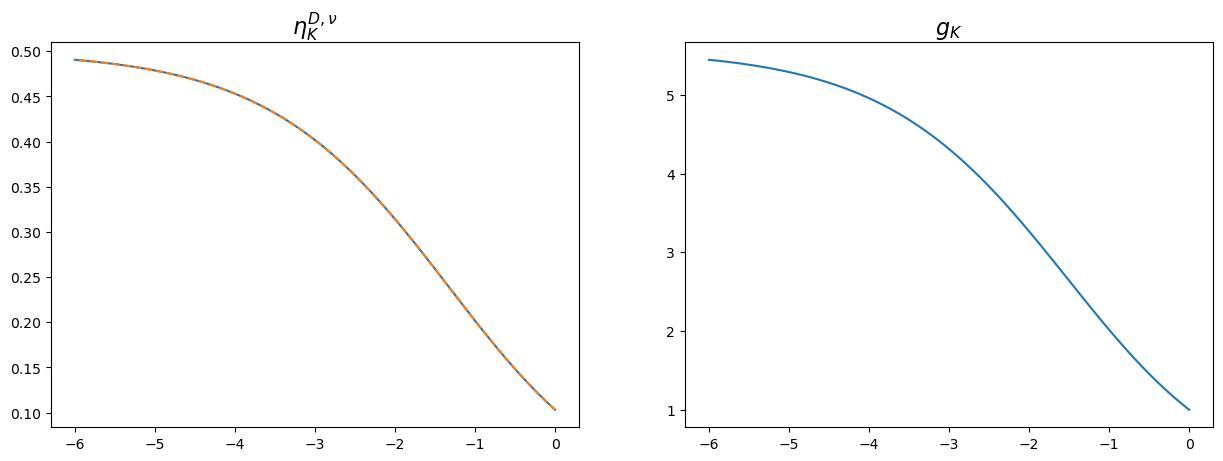

In [11]:
shape_par = (1+n_f+1,)
par = read_par_bin(path_save, 'flow_parameters.bin', shape_par)
s = par[:,0]
eta_D = par[:,1]
eta_nu = par[:,2]
g = par[:,3]

num=2
fig, ax = plt.subplots(1,num, figsize=(7.5*num, 5))

ax[0].set_title(r'$\eta^{D,\nu}_K$', fontsize=16)
ax[0].plot(s, eta_D)
ax[0].plot(s, eta_nu,'--')

ax[1].set_title(r'$g_K$', fontsize=16)
ax[1].plot(s, g)

plt.show()

In [12]:
shape_par = (2+n_f,)
par_exit = read_par_bin(path_save, 'exit_parameters.bin', shape_par)
s_exit = par_exit[:,1]
D_dimf = par_exit[:,2]
nu_dimf =par_exit[:,3]
G = np.load(path_save + '/G20_IC_two.npy', allow_pickle = True)

file = exit_parameters.bin shape = (4,)
n_steps = 200


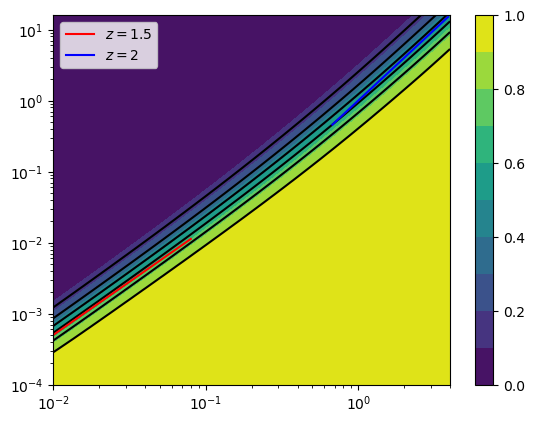

In [31]:
p_two = flow.p_two.copy()
w_two = flow.w_two.copy()

C_decay = np.zeros_like(G)
for ip in range(0,Np_two):
    C_decay[ip,:] = G[ip,:]/G[ip,0]

my_plot_NLO.contourf_Cpw(C_decay, p_two, w_two,
                         cmap=None,  xscale='log', yscale='log', Cscale='linear')

for z, c, ip0, ip1, shift in [(3/2, 'red',0, 70, 0.5), (2,'blue', 140, Np_two-1, 1)]:
    x = p_two[ip0:ip1]
    plt.plot(x, shift * x**z, label=rf'$z={z}$', color=c)

plt.legend()
plt.show()

In [14]:
I_inner = np.array(
    np.loadtxt(
    open(path_save+'/I_inner.dat').readlines()#[:-1]
    )
)
print(I_inner.shape)

I_dimful = read_par_bin(path_save,'I_dimful.bin',(Np_two,))

(6016,)
file = I_dimful.bin shape = (200,)
n_steps = 5992


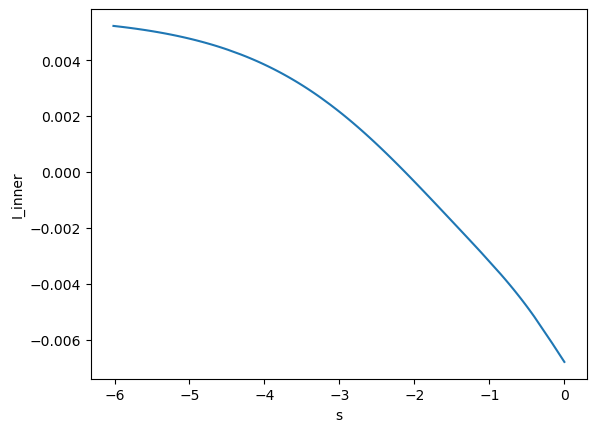

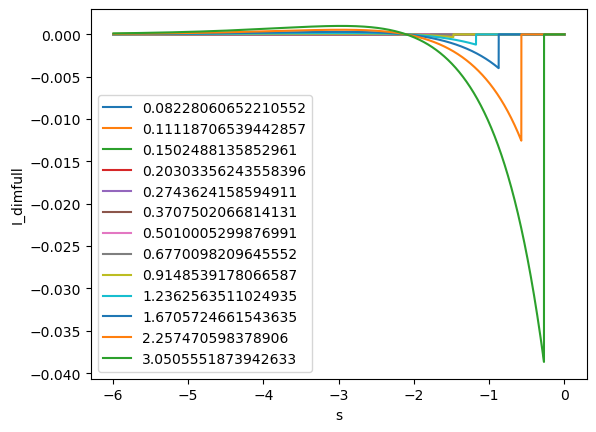

In [19]:
sizeId = I_dimful.shape[0]
sizeI = I_inner.size

sI = -ds*np.arange(sizeI)
sId = -ds*np.arange(sizeId)

js=-1

plt.plot(sI[:js],I_inner[:js])
plt.xlabel('s')
plt.ylabel('I_inner')
plt.show()

for ip_two in range(70,Np_two,10):
    plt.plot(sId[:js],I_dimful[:js,ip_two], label=p_two[ip_two])
plt.xlabel('s')
plt.ylabel('I_dimfull')
plt.legend()
plt.show()